### Imports

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic

### Data loading

In [84]:
functions = {}

for i in range(2, 9):
    X = np.load(f"function_{i}/initial_inputs.npy")
    y = np.load(f"function_{i}/initial_outputs.npy")

    functions[i] = {
        "X": X,
        "y": y
    }

### Reusable GP with kernel function

In [52]:
def run_gp_ucb(function_number, kernel, beta, n_candidates=10000):
    
    # Get data
    X = functions[function_number]["X"]
    y = functions[function_number]["y"]

    # Fit Gaussian Process using chosen kernel
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        optimizer=None
    )

    gp.fit(X, y)

    # Number of input dimensions
    n_dimensions = X.shape[1]

    # Generate candidate points
    candidates = np.random.RandomState(42).uniform(
        0, 1,
        size=(n_candidates, n_dimensions)
    )

    # GP predictions
    mean, std = gp.predict(candidates, return_std=True)

    # UCB
    ucb = mean + beta * std

    # Best candidate
    best_index = np.argmax(ucb)
    best_point = candidates[best_index]

    print(f"Function {function_number}")
    print(f"Kernel: {kernel}")
    print("Suggested point:", np.round(best_point, 6))
    print(f"Predicted mean: {mean[best_index]:.6f}")
    print(f"Uncertainty: {std[best_index]:.6f}")
    print(f"UCB: {ucb[best_index]:.6f}")

    return gp, best_point, mean[best_index], std[best_index]

### Reusable initial observations graph plot function

In [80]:
def plot_initial_observations(function_number):
    
    X = functions[function_number]["X"]
    y = functions[function_number]["y"]
    
    n_dimensions = X.shape[1]

    # 2D functions
    if n_dimensions == 2:
        
        plt.figure(figsize=(8, 6))
        
        scatter = plt.scatter(
            X[:, 0],
            X[:, 1],
            c=y,
            cmap="Blues",
            s=100,
            edgecolors="black"
        )
        
        for i in range(len(X)):
            plt.annotate(
                str(i),
                (X[i, 0], X[i, 1]),
                xytext=(5, 5),
                textcoords="offset points"
            )
        
        plt.colorbar(scatter, label="Observed y")
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.title(f"Function {function_number}: Initial Observations")
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.grid(alpha=0.3)
        plt.show()

    # 3D functions
    elif n_dimensions == 3:
        
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")
        
        scatter = ax.scatter(
            X[:, 0],
            X[:, 1],
            X[:, 2],
            c=y,
            cmap="Blues",
            s=80,
            edgecolors="black"
        )
        
        for i in range(len(X)):
            ax.text(
                X[i, 0],
                X[i, 1],
                X[i, 2],
                str(i)
            )
        
        fig.colorbar(scatter, ax=ax, label="Observed y")
        
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_zlabel("x3")
        ax.set_title(
            f"Function {function_number}: Initial Observations"
        )
        
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_zlim(0, 1)
        
        plt.show()

    else:
        print(
            f"Function {function_number} has {n_dimensions} dimensions. "
            "Direct spatial plotting is only used for 2D or 3D functions."
        )

### Reusable function which plots all 3 kernel results in one graph

In [73]:
def plot_kernel_comparison(
    function_number,
    rbf_point,
    matern_point,
    rq_point
):
    
    plt.figure(figsize=(8, 6))

    # RBF suggestion
    plt.scatter(
        rbf_point[0],
        rbf_point[1],
        marker="o",
        s=180,
        label="RBF"
    )

    # Matérn suggestion
    plt.scatter(
        matern_point[0],
        matern_point[1],
        marker="s",
        s=180,
        label="Matérn"
    )

    # Rational Quadratic suggestion
    plt.scatter(
        rq_point[0],
        rq_point[1],
        marker="^",
        s=180,
        label="Rational Quadratic"
    )

    plt.xlabel("x1")
    plt.ylabel("x2")

    plt.title(
        f"Function {function_number}: Kernel GP-UCB Suggestions"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

### Function 2

In [55]:
X = functions[2]["X"]
y = functions[2]["y"]

df2 = pd.DataFrame(X, columns=["x1", "x2"])
df2["y"] = y

In [56]:
df2.shape

(10, 3)

In [57]:
display(df2)

,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


In [58]:
display(df2.sort_values("y", ascending=False))

,x1,x2,y
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993
6,0.438166,0.685018,0.244619
4,0.454647,0.290455,0.214965
7,0.341750,0.028698,0.038749
5,0.577713,0.771973,0.023106
8,0.338648,0.213867,-0.013858
2,0.142699,0.349005,-0.065624


#### graph plot of function 2 - coloured based on y value (higher means darker)

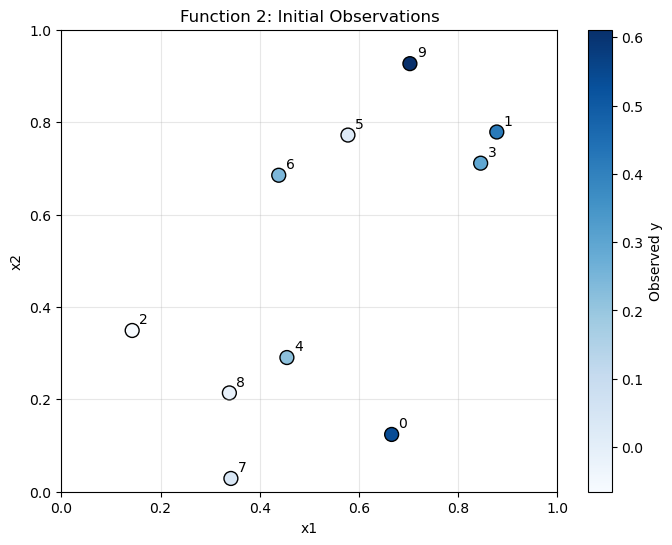

In [82]:
plot_initial_observations(2)

initial hypothesis (could be wrong) but from looking at the more promising data points they seem to be on very similar x1 region - it may be that x1: 0.65-0.75 is the optimal area

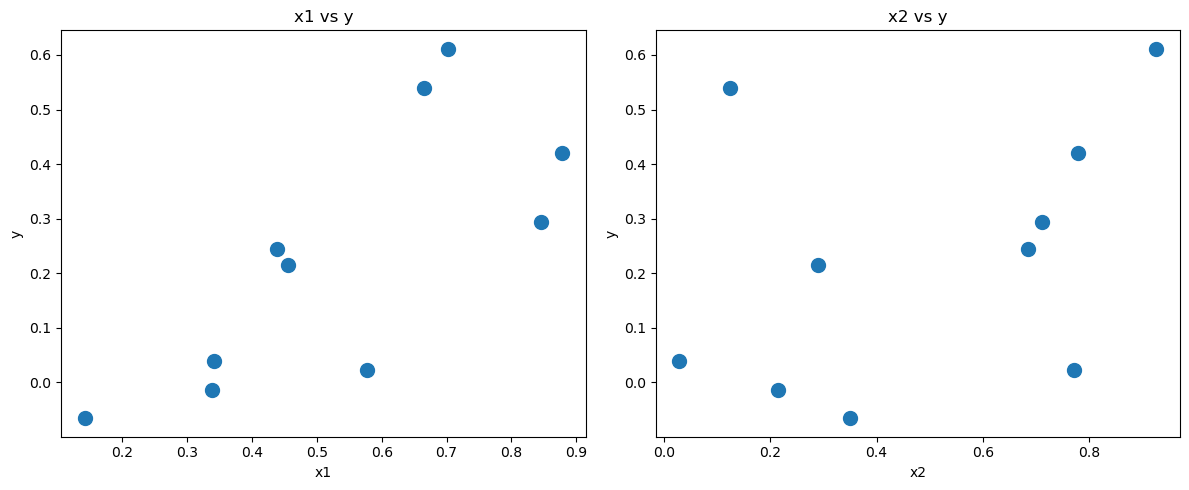

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df2["x1"], df2["y"], s=100)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("y")
axes[0].set_title("x1 vs y")

axes[1].scatter(df2["x2"], df2["y"], s=100)
axes[1].set_xlabel("x2")
axes[1].set_ylabel("y")
axes[1].set_title("x2 vs y")

plt.tight_layout()
plt.show()

There does seem to be a general positive trend in the `x1 vs y` graph, with the output increasing as `x1` increases before appearing to fall after approximately `x1 = 0.7`. However, the observation around `x1 = 0.58` does break this pattern slightly. My initial hypothesis that `x1` may be particularly influential therefore has some support, as the `x2 vs y` graph does not show an obvious trend. However, with only 10 observations, this is still preliminary and the interaction between `x1` and `x2` also needs to be considered.

#### trying GP with RBF 

In [65]:
kernel_rbf = RBF(length_scale=0.1)

gp2_rbf, point2_rbf, mean2_rbf, std2_rbf = run_gp_ucb(
    function_number=2,
    beta = 1.96,
    kernel=kernel_rbf
)

Function 2
Kernel: RBF(length_scale=0.1)
Suggested point: [0.799891 0.925328]
Predicted mean: 0.532661
Uncertainty: 0.166734
UCB: 0.859460


#### trying GP with Matern

In [67]:
kernel_matern = Matern(
    length_scale=0.1,
    nu=2.5
)

In [68]:
gp2_matern, point2_matern, mean2_matern, std2_matern = run_gp_ucb(
    function_number=2,
    kernel=kernel_matern,
    beta=1.96
)

Function 2
Kernel: Matern(length_scale=0.1, nu=2.5)
Suggested point: [0.790415 0.916271]
Predicted mean: 0.498113
Uncertainty: 0.176011
UCB: 0.843094


#### trying GP with RQ

In [70]:
kernel_rq = RationalQuadratic(
    length_scale=0.1,
    alpha=1.0
)

In [71]:
gp2_rq, point2_rq, mean2_rq, std2_rq = run_gp_ucb(
    function_number=2,
    kernel=kernel_rq,
    beta=1.96
)

Function 2
Kernel: RationalQuadratic(alpha=1, length_scale=0.1)
Suggested point: [0.794951 0.966673]
Predicted mean: 0.520404
Uncertainty: 0.164651
UCB: 0.843121


#### plotting all 3 suggestions on one graph

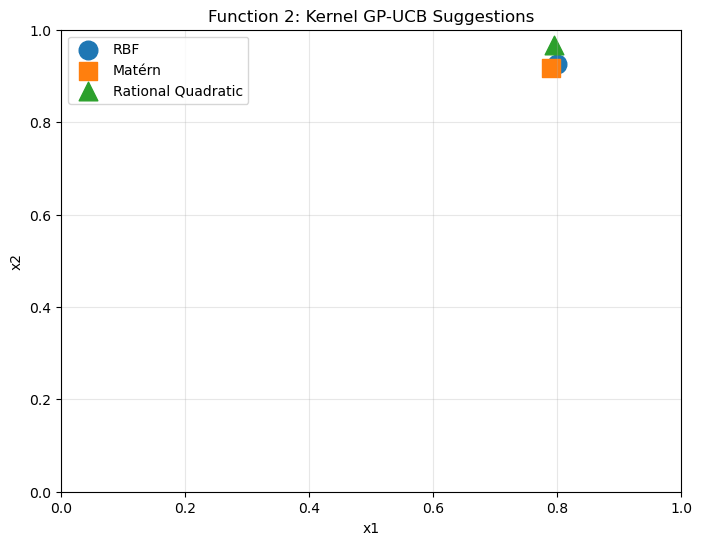

In [75]:
plot_kernel_comparison(
    2,
    point2_rbf,
    point2_matern,
    point2_rq
)

### final query choice

`(0.799891, 0.925328)` - RBF suggestion chosen as it sits nicely in the middle of the 3 kernel suggestions

### Function 3

In [77]:
X3 = functions[3]["X"]
y3 = functions[3]["y"]

df3 = pd.DataFrame(X3, columns=["x1", "x2", "x3"])
df3["y"] = y3

In [78]:
df3

,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


In [79]:
df3.sort_values("y", ascending=False)

,x1,x2,x3,y
3,0.492581,0.611593,0.340176,-0.034835
13,0.600097,0.725136,0.066089,-0.036378
10,0.220549,0.297825,0.343555,-0.046947
4,0.134622,0.219917,0.458206,-0.048008
14,0.965995,0.861120,0.566829,-0.056758
1,0.242114,0.644074,0.272433,-0.087963
9,0.170477,0.697032,0.149169,-0.094190
11,0.666014,0.671985,0.246295,-0.105965
5,0.345523,0.941360,0.269363,-0.110621
2,0.534906,0.398501,0.173389,-0.111415


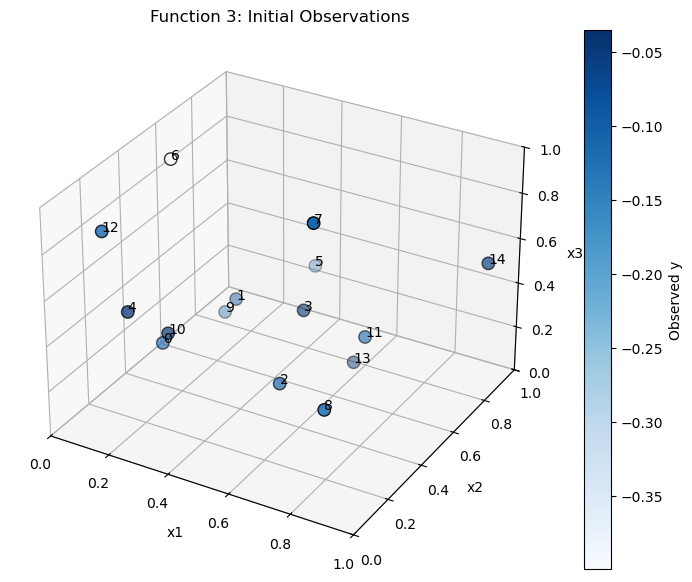

In [85]:
plot_initial_observations(3)

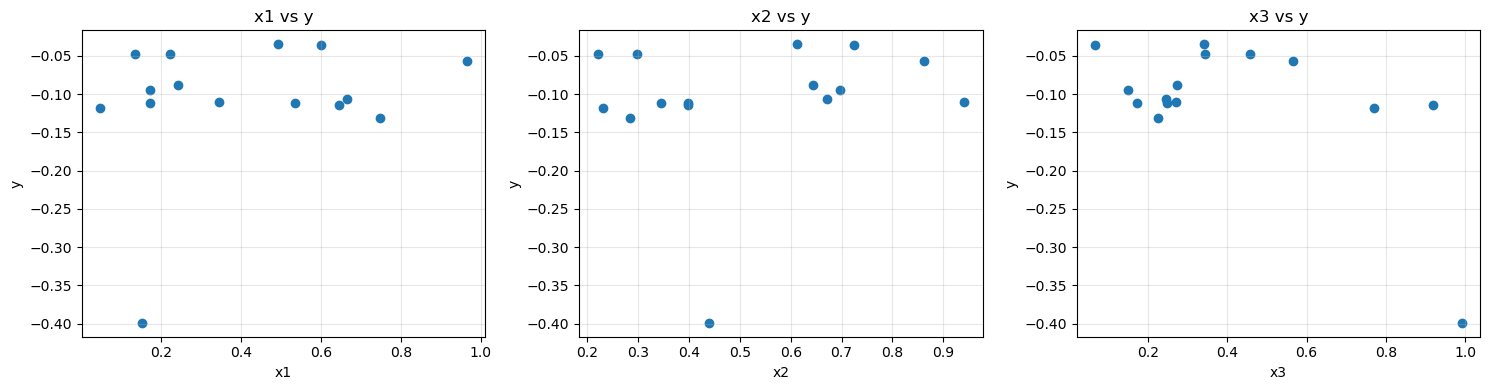

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X3[:, 0], y3)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("y")
axes[0].set_title("x1 vs y")
axes[0].grid(alpha=0.3)

axes[1].scatter(X3[:, 1], y3)
axes[1].set_xlabel("x2")
axes[1].set_ylabel("y")
axes[1].set_title("x2 vs y")
axes[1].grid(alpha=0.3)

axes[2].scatter(X3[:, 2], y3)
axes[2].set_xlabel("x3")
axes[2].set_ylabel("y")
axes[2].set_title("x3 vs y")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()